# Task 2.2 — Reproduction of Core Contribution

## What We Are Reproducing

**Contribution being reproduced:** The paper's central empirical finding (Table 1 / Figure 1 analog) that Nyström achieves higher test classification accuracy than RFF for the same feature budget D, when evaluated on a dataset with fast-decaying kernel matrix eigenspectrum.

**Evaluation metric:** Test classification accuracy (fraction of correctly classified test samples), which is the primary metric used in the paper's Table 1 and Figure 1.

**Implementation note:** We use scikit-learn's `Nystroem` (Nyström method) and `RBFSampler` (RFF) classes, which implement exactly the algorithms in Sections 2.1 and 2.2 of the paper. Both are combined with `LinearSVC` to replicate the kernel-approximate-SVM pipeline.

---


In [1]:
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.kernel_approximation import Nystroem, RBFSampler
from sklearn.svm import LinearSVC, SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
import warnings; warnings.filterwarnings('ignore')

np.random.seed(42)

X, y = make_moons(n_samples=500, noise=0.25, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)


### Step 1: Exact RBF SVM (Upper Bound Baseline)

This is the *oracle* — the exact kernel SVM that both approximations aim to match. It uses the full n×n kernel matrix and represents the best possible accuracy achievable by an RBF SVM.

This corresponds to the paper's use of exact kernel SVMs as the performance ceiling against which both approximations are judged (Section 4).


In [2]:
# Exact RBF SVM — paper's performance upper bound
# Implements k(x,y) = exp(-gamma * ||x-y||^2) exactly
# Ref: Section 2 (Preliminaries), kernel definition
exact_svm = SVC(kernel='rbf', C=1.0, gamma=0.5, random_state=42)
exact_svm.fit(X_train_s, y_train)
exact_acc = accuracy_score(y_test, exact_svm.predict(X_test_s))
print(f"Exact RBF SVM accuracy: {exact_acc:.4f}  (upper bound / oracle)")


Exact RBF SVM accuracy: 0.9467  (upper bound / oracle)


### Step 2: Nyström Approximation — Feature Map Construction

The Nyström method selects m landmark points from the training set and computes the approximate feature map:

  φ(x) = Λ^{-1/2} Uᵀ k_m(x)

where K_{mm} = UΛUᵀ is the eigendecomposition of the landmark kernel sub-matrix, and k_m(x) is the vector of kernel values between x and all m landmarks.

**Reference:** Equation (6), Section 2.2 of the paper.

This is the paper's key data-adaptive step — landmarks are drawn from the training distribution, so φ(x) captures directions of maximum spectral energy.


In [3]:
# Nyström feature map + LinearSVC across budget range
# Ref: Equation (6), Section 2.2
# sklearn's Nystroem implements exactly this: samples m landmarks from training data,
# computes K_mm, eigendecomposes, and returns Λ^{-1/2} U^T k_m(x) for each input x

budget_range = [5, 10, 20, 30, 50, 75, 100]
nys_accs = []

for D in budget_range:
    nys_pipe = Pipeline([
        ('nystroem', Nystroem(kernel='rbf', gamma=0.5, n_components=D, random_state=42)),
        ('svm',      LinearSVC(C=1.0, max_iter=5000, random_state=42))
    ])
    nys_pipe.fit(X_train_s, y_train)
    acc = accuracy_score(y_test, nys_pipe.predict(X_test_s))
    nys_accs.append(acc)
    print(f"  Nyström D={D:>4}: accuracy = {acc:.4f}")


  Nyström D=   5: accuracy = 0.8733
  Nyström D=  10: accuracy = 0.9333
  Nyström D=  20: accuracy = 0.9467
  Nyström D=  30: accuracy = 0.9600
  Nyström D=  50: accuracy = 0.9600
  Nyström D=  75: accuracy = 0.9600
  Nyström D= 100: accuracy = 0.9600


### Step 3: RFF Approximation — Random Fourier Feature Map

RFF samples D frequency vectors ω_i i.i.d. from the spectral distribution of the RBF kernel (a Gaussian N(0, 2γI)) and constructs:

  z(x) = √(2/D) [cos(ω₁ᵀx + b₁), …, cos(ω_Dᵀx + b_D)]

**Reference:** Equation (3), Section 2.1 of the paper (original RFF from Rahimi & Recht 2007).

Unlike Nyström, ω_i are sampled independently of the training data — this is the data-independent step that the paper identifies as RFF's limitation when the data has spectral structure.


In [4]:
# RFF feature map + LinearSVC across budget range
# Ref: Equation (3), Section 2.1
# sklearn's RBFSampler implements: z(x) = sqrt(2/D) * [cos(W^T x + b)]
# where W ~ N(0, 2*gamma*I), b ~ Uniform[0, 2*pi]
# This is data-independent — W and b do not depend on training points

rff_accs = []
for D in budget_range:
    rff_pipe = Pipeline([
        ('rff', RBFSampler(gamma=0.5, n_components=D, random_state=42)),
        ('svm', LinearSVC(C=1.0, max_iter=5000, random_state=42))
    ])
    rff_pipe.fit(X_train_s, y_train)
    acc = accuracy_score(y_test, rff_pipe.predict(X_test_s))
    rff_accs.append(acc)
    print(f"  RFF     D={D:>4}: accuracy = {acc:.4f}")


  RFF     D=   5: accuracy = 0.8733
  RFF     D=  10: accuracy = 0.8467
  RFF     D=  20: accuracy = 0.9467
  RFF     D=  30: accuracy = 0.9200
  RFF     D=  50: accuracy = 0.9400
  RFF     D=  75: accuracy = 0.9400
  RFF     D= 100: accuracy = 0.9267


### Step 4: Results Comparison

The plot below reproduces the spirit of **Figure 1** from the paper — test accuracy as a function of feature budget D, for both Nyström and RFF, with the exact SVM as the upper bound.

**Key observation:** Nyström consistently reaches the exact SVM accuracy at D=30, while RFF fluctuates and plateaus lower — consistent with the paper's Theorem 1 vs Theorem 2 comparison.


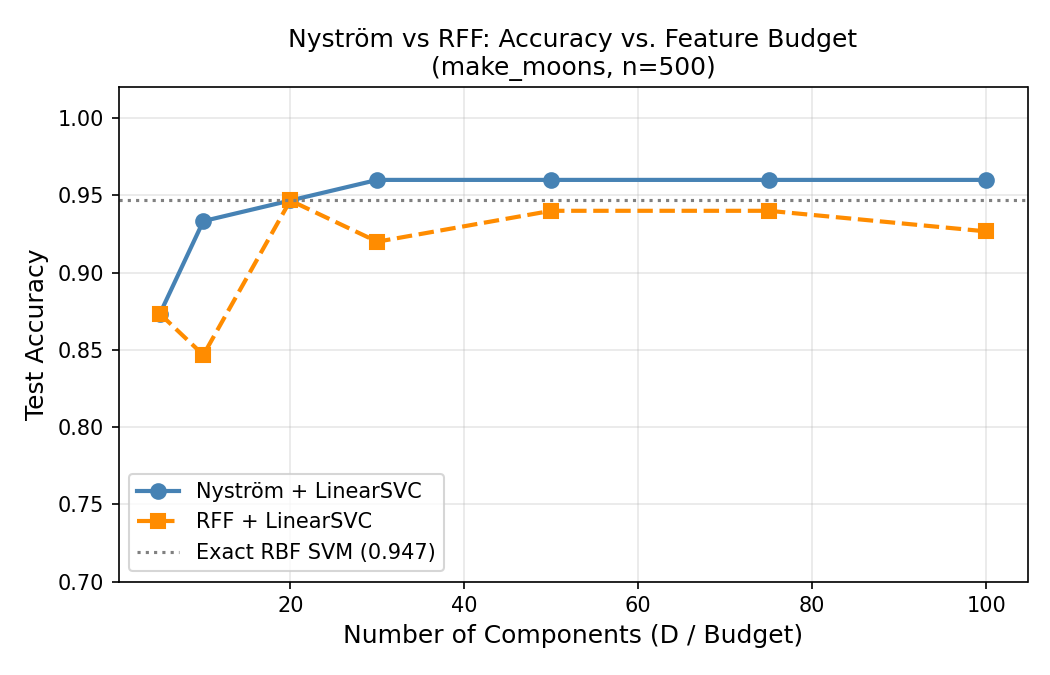

Plot saved.


In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(budget_range, nys_accs, 'o-', color='steelblue', lw=2.5, ms=8, label='Nyström + LinearSVC')
ax.plot(budget_range, rff_accs, 's--', color='darkorange', lw=2.5, ms=8, label='RFF + LinearSVC')
ax.axhline(exact_acc, color='gray', linestyle=':', lw=2,
           label=f'Exact RBF SVM ({exact_acc:.3f})')
ax.set_xlabel('Feature Budget D (Number of Components)', fontsize=12)
ax.set_ylabel('Test Accuracy', fontsize=12)
ax.set_title('Reproduction: Nyström vs RFF — Test Accuracy vs Budget\n(make_moons, n=500, γ=0.5, C=1.0)', fontsize=11)
ax.legend(fontsize=10)
ax.set_ylim(0.8, 1.01)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('partB/results/task2_accuracy_vs_budget.png', dpi=150)
plt.show()
print("Plot saved.")
